# 🎧 Headphones Market Analysis - Deep Dive EDA

**Amazon Electronics - Headphones Segment**  
**Date:** October 29, 2025

## Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import psycopg2
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
print("✅ Libraries loaded!")

✅ Libraries loaded!


## 1. Load Headphones Data

In [9]:
conn = psycopg2.connect(
    host="localhost",
    database="amazon_electronics_rag",
    user="shivamsharma",
    port="5432"
)

# Get all headphone-related categories
query = """
SELECT main_category, COUNT(*) as count 
FROM products 
WHERE main_category ILIKE '%headphone%' 
   OR main_category ILIKE '%audio%'
   OR main_category ILIKE '%earbud%'
GROUP BY main_category
ORDER BY count DESC;
"""

categories = pd.read_sql_query(query, conn)
print("🎧 Headphone-related categories:\n")
print(categories)
print(f"\nTotal categories: {len(categories)}")

🎧 Headphone-related categories:

                  main_category  count
0          Home Audio & Theater  26249
1  Portable Audio & Accessories    898
2            Audible Audiobooks      1

Total categories: 3


In [10]:
# Load headphone products directly (26,198 products based on title keywords)
query = """
SELECT parent_asin, title, description, features, average_rating, 
       rating_number, price, main_category, store, images, blair_embedding
FROM products 
WHERE title ILIKE '%headphone%'
   OR title ILIKE '%earbud%'
   OR title ILIKE '%earphone%'
   OR title ILIKE '%airpod%'
   OR title ILIKE '%headset%';
"""

df = pd.read_sql_query(query, conn)
conn.close()  # Close AFTER loading data

print(f"✅ Loaded {len(df):,} headphone products")
print(f"   Columns: {df.shape[1]}")
print(f"\nCategory breakdown:")
print(df['main_category'].value_counts().head(10))

✅ Loaded 29,568 headphone products
   Columns: 11

Category breakdown:
main_category
All Electronics              15211
Cell Phones & Accessories     5178
Home Audio & Theater          5118
Computers                     1125
Industrial & Scientific        845
Musical Instruments            398
Office Products                180
Camera & Photo                 116
Car Electronics                114
Apple Products                  97
Name: count, dtype: int64


## 2. Filter to Pure Headphone Products

In [11]:
# Filter by title keywords to ensure we only get actual headphones
headphone_keywords = ['headphone', 'earbud', 'earphone', 'airpod', 'earpiece', 
                      'in-ear', 'over-ear', 'on-ear', 'bluetooth headset']

def is_headphone(title):
    title_lower = str(title).lower()
    return any(keyword in title_lower for keyword in headphone_keywords)

df['is_headphone'] = df['title'].apply(is_headphone)
df_hp = df[df['is_headphone']].copy()

print(f"📊 Filtered to {len(df_hp):,} pure headphone products")
print(f"   Removed {len(df) - len(df_hp):,} non-headphone products")
print(f"\nPrice data: {df_hp['price'].notna().sum():,} products ({df_hp['price'].notna().sum()/len(df_hp)*100:.1f}%)")
print(f"Rating data: {df_hp['average_rating'].notna().sum():,} products ({df_hp['average_rating'].notna().sum()/len(df_hp)*100:.1f}%)")

📊 Filtered to 27,245 pure headphone products
   Removed 2,323 non-headphone products

Price data: 11,310 products (41.5%)
Rating data: 27,245 products (100.0%)


## 3. Feature Engineering for Headphones

In [12]:
print("🔧 Creating headphone-specific features...\n")

# Price segments
df_hp['price_segment'] = pd.cut(
    df_hp['price'], 
    bins=[0, 20, 50, 100, 200, 1000], 
    labels=['Budget (<$20)', 'Entry ($20-50)', 'Mid-Range ($50-100)', 
            'Premium ($100-200)', 'Luxury (>$200)']
)

# Rating tiers
df_hp['rating_tier'] = pd.cut(
    df_hp['average_rating'],
    bins=[0, 3.5, 4.0, 4.5, 5.0],
    labels=['Below Avg (<3.5)', 'Average (3.5-4.0)', 'Good (4.0-4.5)', 'Excellent (4.5-5.0)']
)

# Review volume
df_hp['review_volume'] = pd.cut(
    df_hp['rating_number'],
    bins=[-1, 50, 200, 1000, 100000],
    labels=['Low (<50)', 'Medium (50-200)', 'High (200-1K)', 'Very High (>1K)']
)

# Headphone type detection
def detect_type(title):
    title_lower = str(title).lower()
    if 'wireless' in title_lower or 'bluetooth' in title_lower:
        return 'Wireless'
    elif 'wired' in title_lower or 'cable' in title_lower:
        return 'Wired'
    else:
        return 'Unknown'

def detect_form_factor(title):
    title_lower = str(title).lower()
    if 'earbud' in title_lower or 'in-ear' in title_lower or 'airpod' in title_lower:
        return 'Earbuds/In-Ear'
    elif 'over-ear' in title_lower or 'over ear' in title_lower:
        return 'Over-Ear'
    elif 'on-ear' in title_lower or 'on ear' in title_lower:
        return 'On-Ear'
    else:
        return 'Unknown'

df_hp['connectivity'] = df_hp['title'].apply(detect_type)
df_hp['form_factor'] = df_hp['title'].apply(detect_form_factor)

# Brand extraction
df_hp['brand'] = df_hp['title'].str.split().str[0]

# Popularity score
scaler = MinMaxScaler()
df_hp['popularity_score'] = (
    scaler.fit_transform(df_hp[['rating_number']].fillna(0)) * 0.6 +
    scaler.fit_transform(df_hp[['average_rating']].fillna(0)) * 0.4
).flatten()

# Value score (lower price per rating = better value)
df_hp['value_score'] = df_hp['price'] / (df_hp['average_rating'] + 0.01)

print("✅ Created features:")
print("   • price_segment, rating_tier, review_volume")
print("   • connectivity (Wireless/Wired)")
print("   • form_factor (Earbuds/Over-Ear/On-Ear)")
print("   • popularity_score, value_score")
print(f"\n📊 Dataset now has {df_hp.shape[1]} columns")

🔧 Creating headphone-specific features...

✅ Created features:
   • price_segment, rating_tier, review_volume
   • connectivity (Wireless/Wired)
   • form_factor (Earbuds/Over-Ear/On-Ear)
   • popularity_score, value_score

📊 Dataset now has 20 columns


## 4. Market Overview Statistics

In [14]:
print("="*70)
print("🎧 HEADPHONES MARKET OVERVIEW")
print("="*70)
print(f"Total Products: {len(df_hp):,}")
print(f"\nPRICE:")
print(f"  • Median: ${df_hp['price'].median():.2f}")
print(f"  • Mean: ${df_hp['price'].mean():.2f}")
print(f"  • Range: ${df_hp['price'].min():.2f} - ${df_hp['price'].max():.2f}")
print(f"\nRATINGS:")
print(f"  • Average: {df_hp['average_rating'].mean():.2f}★")
print(f"  • Median reviews: {df_hp['rating_number'].median():.0f}")
print(f"  • Products with 4.5+★: {len(df_hp[df_hp['average_rating'] >= 4.5]):,} ({len(df_hp[df_hp['average_rating'] >= 4.5])/len(df_hp)*100:.1f}%)")
print(f"\nCONNECTIVITY:")
print(df_hp['connectivity'].value_counts())
print(f"\nFORM FACTOR:")
print(df_hp['form_factor'].value_counts())
print(f"\nTOP 5 BRANDS:")
print(df_hp['brand'].value_counts().head(5))
print("="*70)

🎧 HEADPHONES MARKET OVERVIEW
Total Products: 27,245

PRICE:
  • Median: $18.99
  • Mean: $44.76
  • Range: $0.65 - $2999.00

RATINGS:
  • Average: 3.99★
  • Median reviews: 156
  • Products with 4.5+★: 4,308 (15.8%)

CONNECTIVITY:
connectivity
Unknown     12535
Wireless     9627
Wired        5083
Name: count, dtype: int64

FORM FACTOR:
form_factor
Unknown           12957
Earbuds/In-Ear    11705
Over-Ear           1561
On-Ear             1022
Name: count, dtype: int64

TOP 5 BRANDS:
brand
Sony          637
Wireless      589
Bluetooth     448
USB           414
Sennheiser    344
Name: count, dtype: int64


## 5. Price Segment Analysis

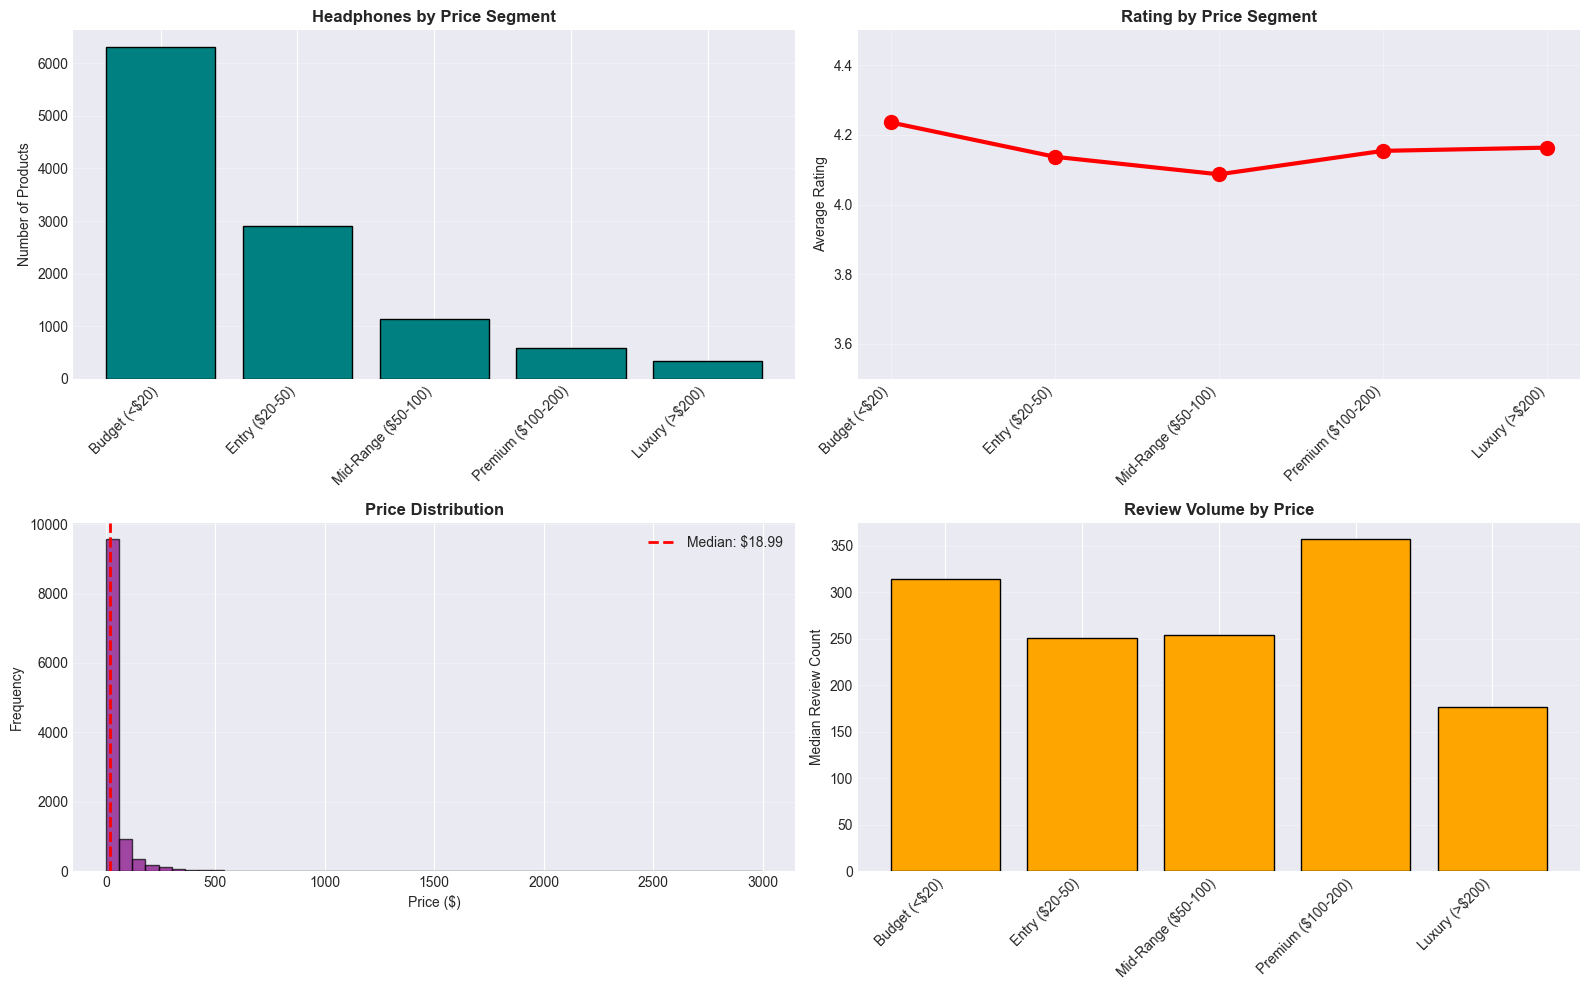


💰 Most common: Budget (<$20) (6,313 products)
⭐ Highest rated: Budget (<$20) (4.24★)
📈 Most reviewed: Premium ($100-200) (357 median reviews)


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Products per price segment
price_counts = df_hp['price_segment'].value_counts().sort_index()
axes[0,0].bar(range(len(price_counts)), price_counts.values, color='teal', edgecolor='black')
axes[0,0].set_xticks(range(len(price_counts)))
axes[0,0].set_xticklabels(price_counts.index, rotation=45, ha='right')
axes[0,0].set_ylabel('Number of Products')
axes[0,0].set_title('Headphones by Price Segment', fontweight='bold', fontsize=12)
axes[0,0].grid(axis='y', alpha=0.3)

# Rating by price segment
price_rating = df_hp.groupby('price_segment')['average_rating'].mean().sort_index()
axes[0,1].plot(range(len(price_rating)), price_rating.values, marker='o', linewidth=3, markersize=10, color='red')
axes[0,1].set_xticks(range(len(price_rating)))
axes[0,1].set_xticklabels(price_rating.index, rotation=45, ha='right')
axes[0,1].set_ylabel('Average Rating')
axes[0,1].set_title('Rating by Price Segment', fontweight='bold', fontsize=12)
axes[0,1].grid(True, alpha=0.3)
axes[0,1].set_ylim([3.5, 4.5])

# Price distribution
valid_prices = df_hp['price'].dropna()
axes[1,0].hist(valid_prices, bins=50, color='purple', alpha=0.7, edgecolor='black')
axes[1,0].set_xlabel('Price ($)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Price Distribution', fontweight='bold', fontsize=12)
axes[1,0].axvline(valid_prices.median(), color='red', linestyle='--', linewidth=2, label=f'Median: ${valid_prices.median():.2f}')
axes[1,0].legend()
axes[1,0].grid(axis='y', alpha=0.3)

# Reviews by price segment
price_reviews = df_hp.groupby('price_segment')['rating_number'].median().sort_index()
axes[1,1].bar(range(len(price_reviews)), price_reviews.values, color='orange', edgecolor='black')
axes[1,1].set_xticks(range(len(price_reviews)))
axes[1,1].set_xticklabels(price_reviews.index, rotation=45, ha='right')
axes[1,1].set_ylabel('Median Review Count')
axes[1,1].set_title('Review Volume by Price', fontweight='bold', fontsize=12)
axes[1,1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n💰 Most common: {price_counts.idxmax()} ({price_counts.max():,} products)")
print(f"⭐ Highest rated: {price_rating.idxmax()} ({price_rating.max():.2f}★)")
print(f"📈 Most reviewed: {price_reviews.idxmax()} ({price_reviews.max():.0f} median reviews)")

## 6. Wireless vs Wired Analysis

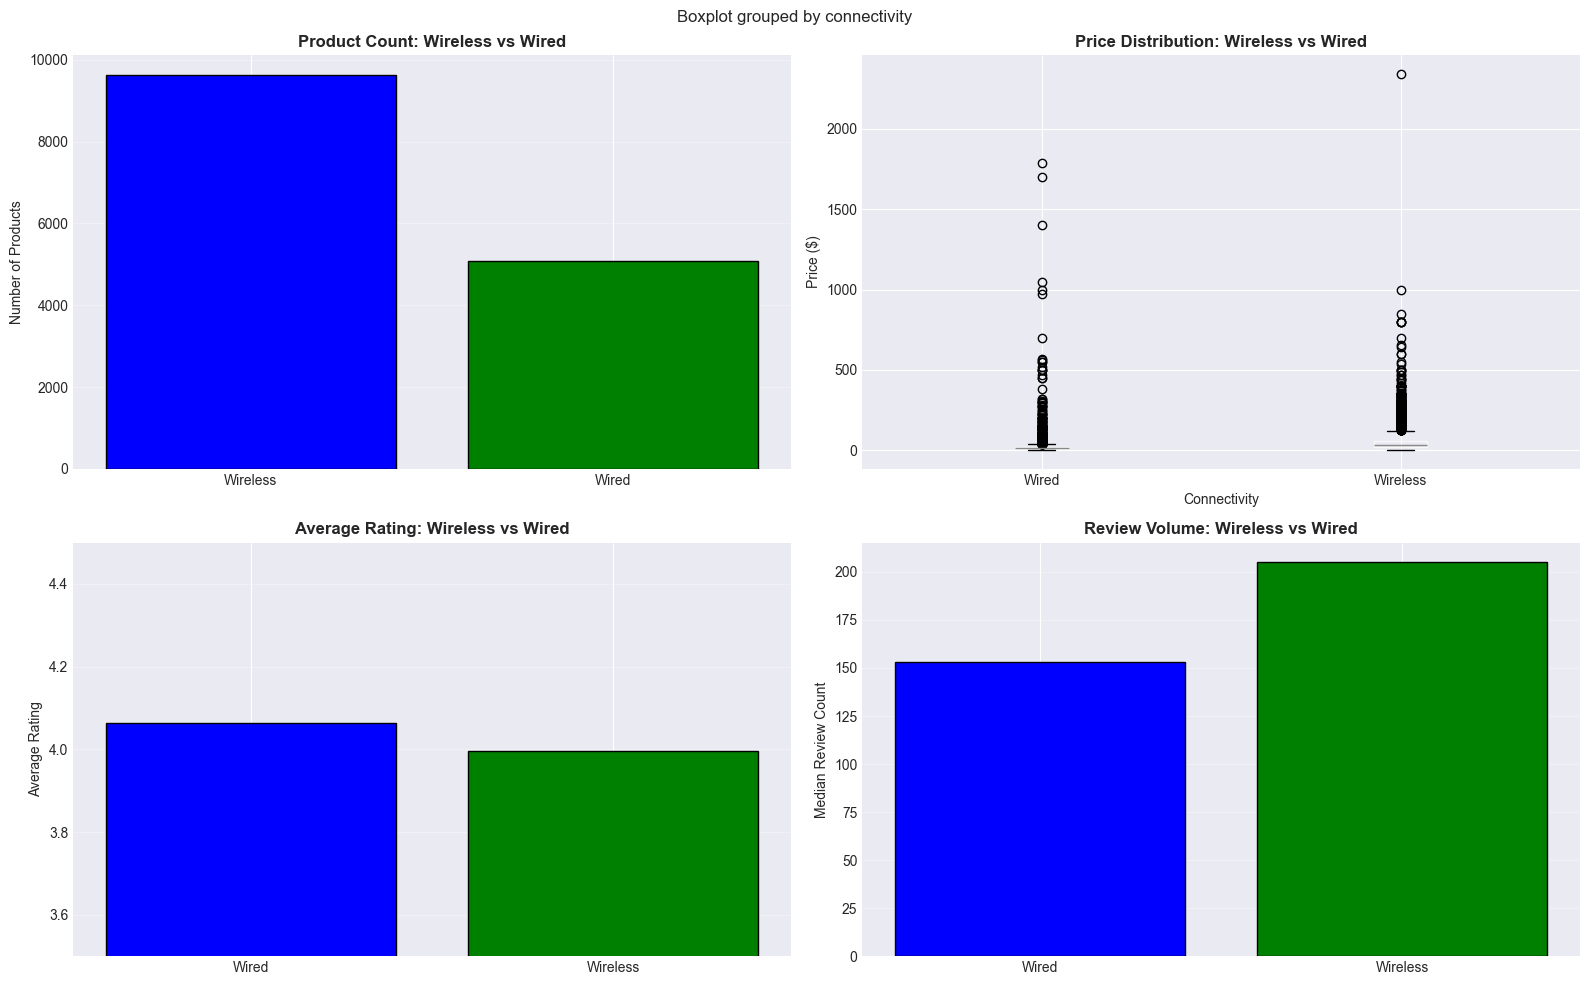


📊 WIRELESS vs WIRED COMPARISON:

Wireless:
  • Count: 9,627
  • Median Price: $29.99
  • Avg Rating: 4.00★
  • Median Reviews: 205

Wired:
  • Count: 5,083
  • Median Price: $13.99
  • Avg Rating: 4.06★
  • Median Reviews: 153


In [16]:
# Compare wireless vs wired
conn_data = df_hp[df_hp['connectivity'].isin(['Wireless', 'Wired'])].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Count
conn_counts = conn_data['connectivity'].value_counts()
axes[0,0].bar(conn_counts.index, conn_counts.values, color=['blue', 'green'], edgecolor='black')
axes[0,0].set_ylabel('Number of Products')
axes[0,0].set_title('Product Count: Wireless vs Wired', fontweight='bold', fontsize=12)
axes[0,0].grid(axis='y', alpha=0.3)

# Price comparison
conn_data.boxplot(column='price', by='connectivity', ax=axes[0,1])
axes[0,1].set_title('Price Distribution: Wireless vs Wired', fontweight='bold', fontsize=12)
axes[0,1].set_xlabel('Connectivity')
axes[0,1].set_ylabel('Price ($)')
plt.sca(axes[0,1])
plt.xticks(rotation=0)

# Rating comparison
conn_ratings = conn_data.groupby('connectivity')['average_rating'].mean()
axes[1,0].bar(conn_ratings.index, conn_ratings.values, color=['blue', 'green'], edgecolor='black')
axes[1,0].set_ylabel('Average Rating')
axes[1,0].set_title('Average Rating: Wireless vs Wired', fontweight='bold', fontsize=12)
axes[1,0].set_ylim([3.5, 4.5])
axes[1,0].grid(axis='y', alpha=0.3)

# Review volume
conn_reviews = conn_data.groupby('connectivity')['rating_number'].median()
axes[1,1].bar(conn_reviews.index, conn_reviews.values, color=['blue', 'green'], edgecolor='black')
axes[1,1].set_ylabel('Median Review Count')
axes[1,1].set_title('Review Volume: Wireless vs Wired', fontweight='bold', fontsize=12)
axes[1,1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 WIRELESS vs WIRED COMPARISON:")
for conn_type in ['Wireless', 'Wired']:
    data = conn_data[conn_data['connectivity'] == conn_type]
    print(f"\n{conn_type}:")
    print(f"  • Count: {len(data):,}")
    print(f"  • Median Price: ${data['price'].median():.2f}")
    print(f"  • Avg Rating: {data['average_rating'].mean():.2f}★")
    print(f"  • Median Reviews: {data['rating_number'].median():.0f}")

## 7. Form Factor Analysis (Earbuds vs Over-Ear vs On-Ear)

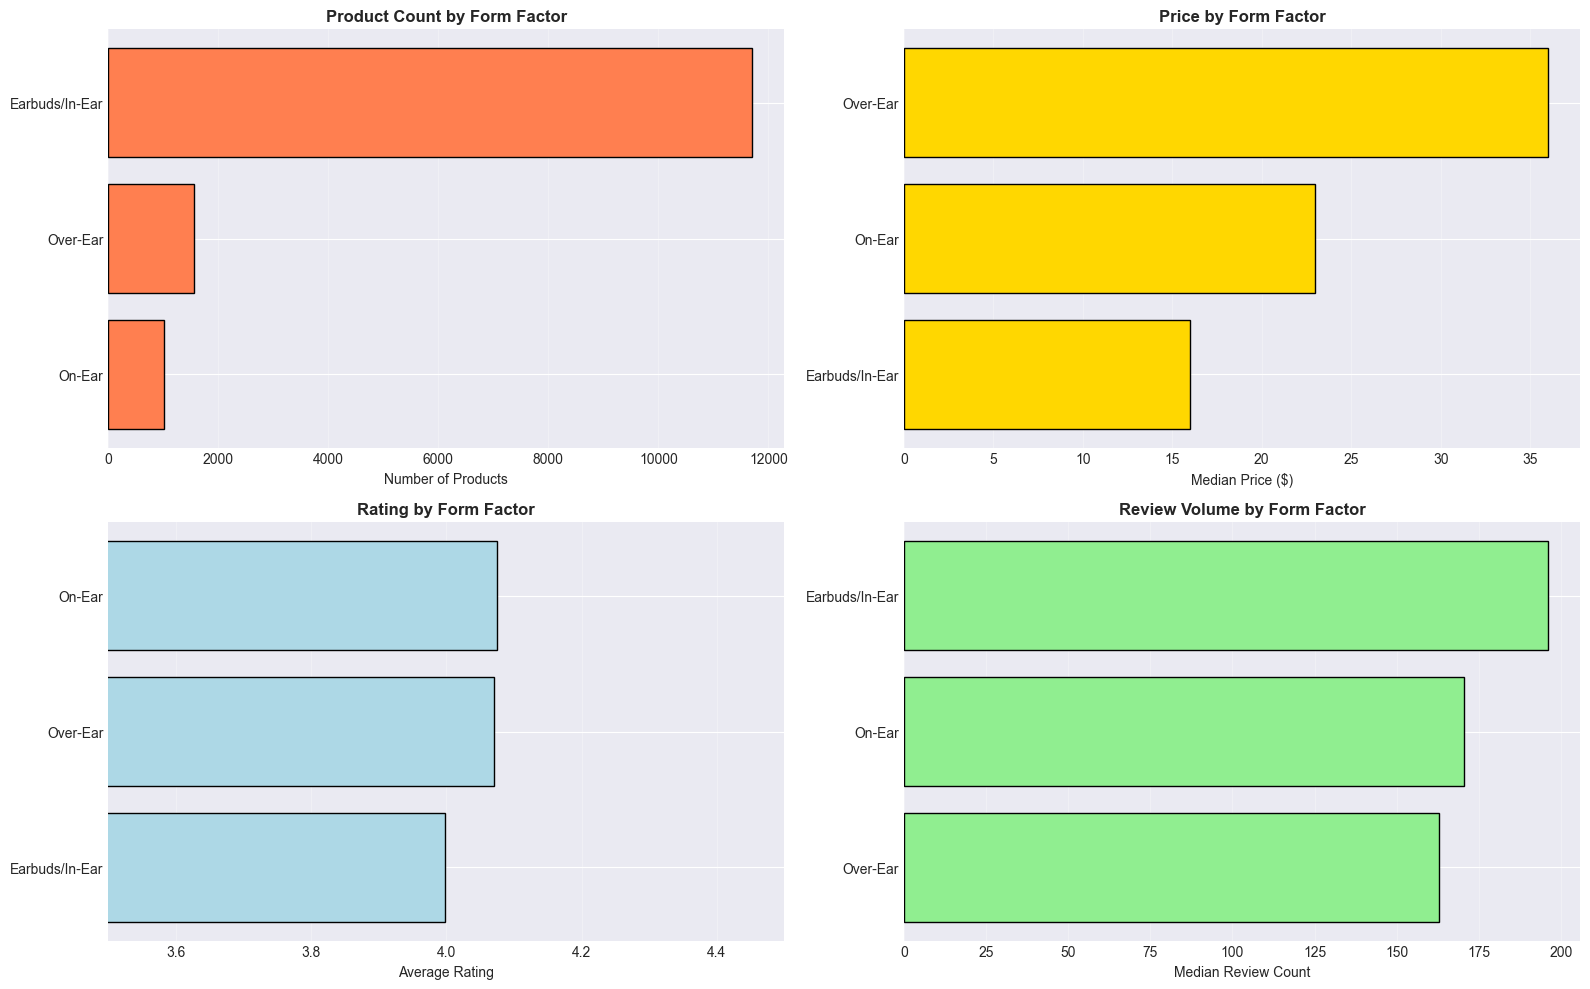


🎧 FORM FACTOR COMPARISON:

Earbuds/In-Ear:
  • Count: 11,705
  • Median Price: $15.99
  • Avg Rating: 4.00★
  • Median Reviews: 196

Over-Ear:
  • Count: 1,561
  • Median Price: $35.98
  • Avg Rating: 4.07★
  • Median Reviews: 163

On-Ear:
  • Count: 1,022
  • Median Price: $22.98
  • Avg Rating: 4.08★
  • Median Reviews: 170


In [17]:
# Filter known form factors
ff_data = df_hp[df_hp['form_factor'] != 'Unknown'].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Count
ff_counts = ff_data['form_factor'].value_counts()
axes[0,0].barh(range(len(ff_counts)), ff_counts.values, color='coral', edgecolor='black')
axes[0,0].set_yticks(range(len(ff_counts)))
axes[0,0].set_yticklabels(ff_counts.index)
axes[0,0].set_xlabel('Number of Products')
axes[0,0].set_title('Product Count by Form Factor', fontweight='bold', fontsize=12)
axes[0,0].invert_yaxis()
axes[0,0].grid(axis='x', alpha=0.3)

# Price by form factor
ff_price = ff_data.groupby('form_factor')['price'].median().sort_values(ascending=False)
axes[0,1].barh(range(len(ff_price)), ff_price.values, color='gold', edgecolor='black')
axes[0,1].set_yticks(range(len(ff_price)))
axes[0,1].set_yticklabels(ff_price.index)
axes[0,1].set_xlabel('Median Price ($)')
axes[0,1].set_title('Price by Form Factor', fontweight='bold', fontsize=12)
axes[0,1].invert_yaxis()
axes[0,1].grid(axis='x', alpha=0.3)

# Rating by form factor
ff_rating = ff_data.groupby('form_factor')['average_rating'].mean().sort_values(ascending=False)
axes[1,0].barh(range(len(ff_rating)), ff_rating.values, color='lightblue', edgecolor='black')
axes[1,0].set_yticks(range(len(ff_rating)))
axes[1,0].set_yticklabels(ff_rating.index)
axes[1,0].set_xlabel('Average Rating')
axes[1,0].set_title('Rating by Form Factor', fontweight='bold', fontsize=12)
axes[1,0].invert_yaxis()
axes[1,0].set_xlim([3.5, 4.5])
axes[1,0].grid(axis='x', alpha=0.3)

# Review volume
ff_reviews = ff_data.groupby('form_factor')['rating_number'].median().sort_values(ascending=False)
axes[1,1].barh(range(len(ff_reviews)), ff_reviews.values, color='lightgreen', edgecolor='black')
axes[1,1].set_yticks(range(len(ff_reviews)))
axes[1,1].set_yticklabels(ff_reviews.index)
axes[1,1].set_xlabel('Median Review Count')
axes[1,1].set_title('Review Volume by Form Factor', fontweight='bold', fontsize=12)
axes[1,1].invert_yaxis()
axes[1,1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🎧 FORM FACTOR COMPARISON:")
for ff in ff_counts.index:
    data = ff_data[ff_data['form_factor'] == ff]
    print(f"\n{ff}:")
    print(f"  • Count: {len(data):,}")
    print(f"  • Median Price: ${data['price'].median():.2f}")
    print(f"  • Avg Rating: {data['average_rating'].mean():.2f}★")
    print(f"  • Median Reviews: {data['rating_number'].median():.0f}")

## 8. Top Brands Analysis

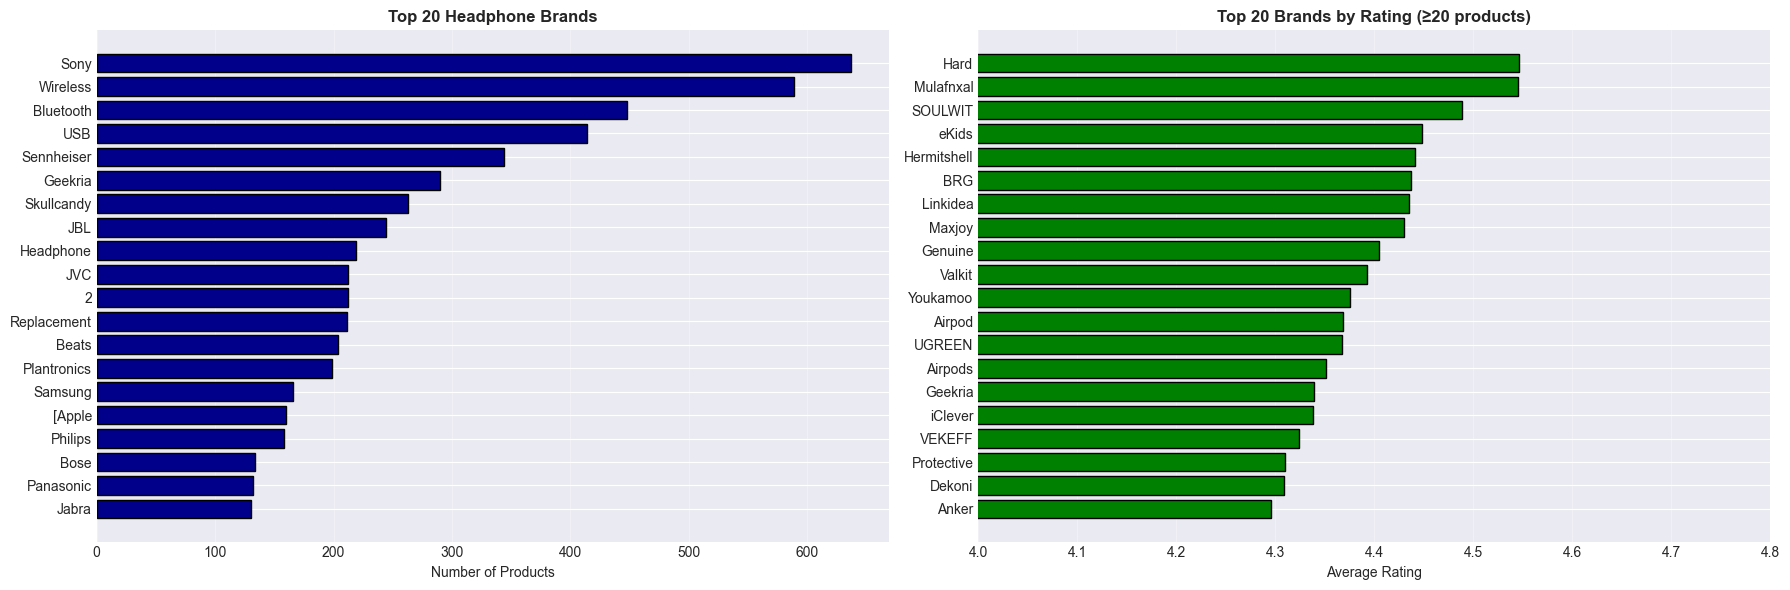


🏆 Most products: Sony (637)
🌟 Highest rated: Hard (4.55★)
🏷️  Total brands: 6,113


In [18]:
top_brands = df_hp['brand'].value_counts().head(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top 20 brands by count
axes[0].barh(range(len(top_brands)), top_brands.values, color='darkblue', edgecolor='black')
axes[0].set_yticks(range(len(top_brands)))
axes[0].set_yticklabels(top_brands.index)
axes[0].set_xlabel('Number of Products')
axes[0].set_title('Top 20 Headphone Brands', fontweight='bold', fontsize=12)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Top brands by rating (min 20 products)
brand_stats = df_hp.groupby('brand').agg({
    'average_rating': 'mean',
    'parent_asin': 'count',
    'price': 'median'
}).rename(columns={'parent_asin': 'count'})
brand_stats = brand_stats[brand_stats['count'] >= 20]
top_rated_brands = brand_stats.nlargest(20, 'average_rating')

axes[1].barh(range(len(top_rated_brands)), top_rated_brands['average_rating'].values, color='green', edgecolor='black')
axes[1].set_yticks(range(len(top_rated_brands)))
axes[1].set_yticklabels(top_rated_brands.index)
axes[1].set_xlabel('Average Rating')
axes[1].set_title('Top 20 Brands by Rating (≥20 products)', fontweight='bold', fontsize=12)
axes[1].invert_yaxis()
axes[1].set_xlim([4.0, 4.8])
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n🏆 Most products: {top_brands.index[0]} ({top_brands.values[0]:,})")
print(f"🌟 Highest rated: {top_rated_brands.index[0]} ({top_rated_brands.iloc[0]['average_rating']:.2f}★)")
print(f"🏷️  Total brands: {df_hp['brand'].nunique():,}")

## 9. Headphone-Specific Keywords (TF-IDF)

📝 Analyzing headphone keywords...

Top 20 Headphone-Specific Keywords:

 1. headphones                        4,107.8
 2. ear                               3,180.3
 3. headphone                         2,644.3
 4. wireless                          2,527.6
 5. bluetooth                         2,508.2
 6. black                             2,373.9
 7. earbuds                           2,156.1
 8. headset                           1,894.5
 9. case                              1,818.3
10. stereo                            1,749.9
11. earphones                         1,612.5
12. noise                             1,518.5
13. audio                             1,485.7
14. mic                               1,439.1
15. cable                             1,399.4
16. 5mm                               1,352.9
17. microphone                        1,301.2
18. ear headphones                    1,282.8
19. airpods                           1,274.0
20. compatible                        1,254.7


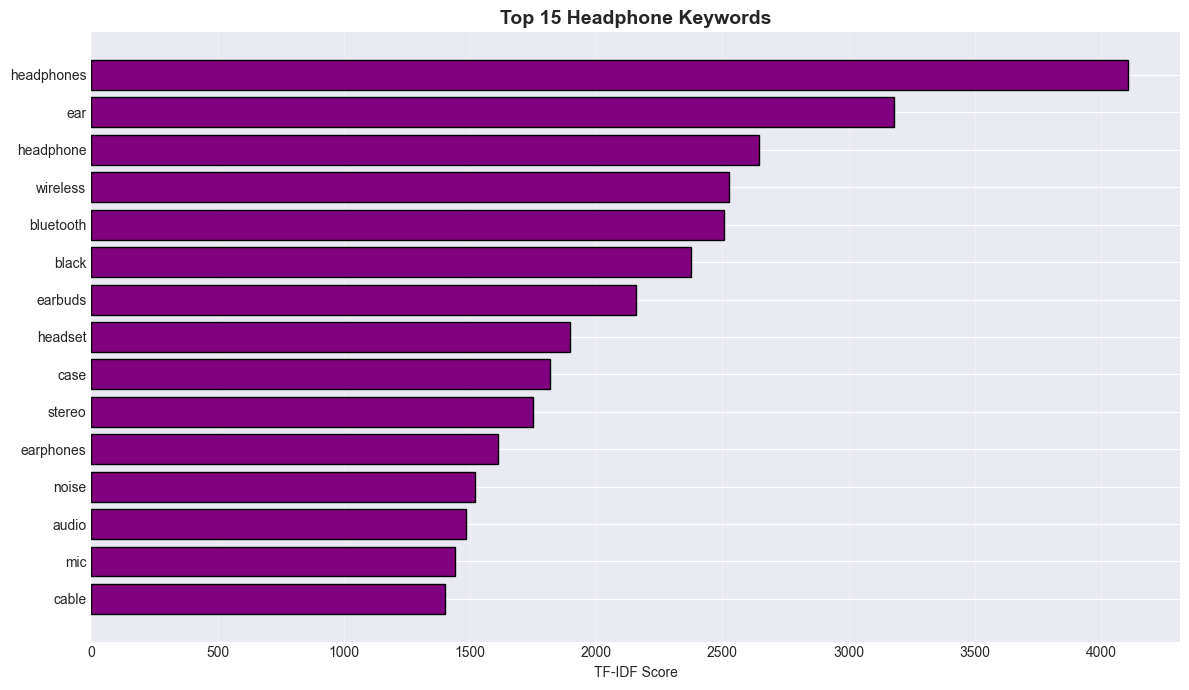

In [20]:
print("📝 Analyzing headphone keywords...\n")

titles = df_hp['title'].fillna('').str.lower()
tfidf = TfidfVectorizer(max_features=50, stop_words='english', ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(titles)

feature_names = tfidf.get_feature_names_out()
tfidf_scores = tfidf_matrix.sum(axis=0).A1
top_terms = sorted(zip(feature_names, tfidf_scores), key=lambda x: x[1], reverse=True)[:20]

print("Top 20 Headphone-Specific Keywords:\n")
for i, (term, score) in enumerate(top_terms, 1):
    print(f"{i:2d}. {term:30s} {score:10,.1f}")

terms, scores = zip(*top_terms[:15])
plt.figure(figsize=(12, 7))
plt.barh(range(len(terms)), scores, color='purple', edgecolor='black')
plt.yticks(range(len(terms)), terms)
plt.xlabel('TF-IDF Score')
plt.title('Top 15 Headphone Keywords', fontweight='bold', fontsize=14)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Best Value Headphones

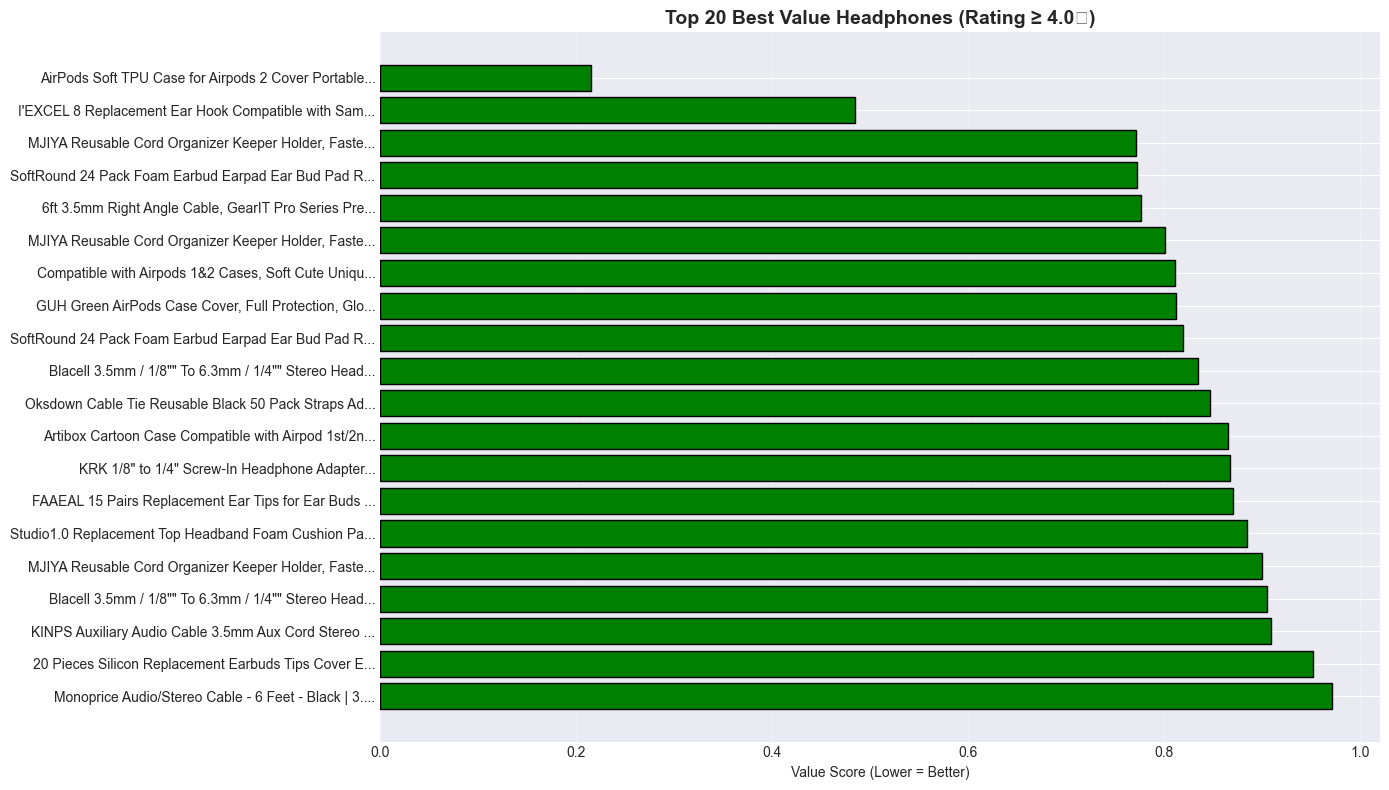


💎 TOP 5 BEST VALUE HEADPHONES:

1. AirPods Soft TPU Case for Airpods 2 Cover Portable Cute Butt...
   Price: $0.99 | Rating: 4.60★ | Reviews: 165
   Type: Unknown | Value Score: 0.21

2. I'EXCEL 8 Replacement Ear Hook Compatible with Samsung Hm130...
   Price: $1.99 | Rating: 4.10★ | Reviews: 241
   Type: Wireless | Value Score: 0.48

3. MJIYA Reusable Cord Organizer Keeper Holder, Fastening Cable...
   Price: $3.71 | Rating: 4.80★ | Reviews: 16
   Type: Wired | Value Score: 0.77

4. SoftRound 24 Pack Foam Earbud Earpad Ear Bud Pad Replacement...
   Price: $3.25 | Rating: 4.20★ | Reviews: 2,665
   Type: Unknown | Value Score: 0.77

5. 6ft 3.5mm Right Angle Cable, GearIT Pro Series Premium Gold ...
   Price: $3.50 | Rating: 4.50★ | Reviews: 37
   Type: Wired | Value Score: 0.78



In [21]:
# Find best value headphones (high rating, low price per rating)
high_rated_hp = df_hp[df_hp['average_rating'] >= 4.0].copy()
best_value_hp = high_rated_hp.nsmallest(20, 'value_score')[['title', 'price', 'average_rating', 'rating_number', 'connectivity', 'value_score']]

plt.figure(figsize=(14, 8))
plt.barh(range(len(best_value_hp)), best_value_hp['value_score'].values, color='green', edgecolor='black')
plt.yticks(range(len(best_value_hp)), [t[:50] + '...' for t in best_value_hp['title']])
plt.xlabel('Value Score (Lower = Better)')
plt.title('Top 20 Best Value Headphones (Rating ≥ 4.0★)', fontweight='bold', fontsize=14)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💎 TOP 5 BEST VALUE HEADPHONES:\n")
for i, (idx, row) in enumerate(best_value_hp.head(5).iterrows(), 1):
    print(f"{i}. {row['title'][:60]}...")
    print(f"   Price: ${row['price']:.2f} | Rating: {row['average_rating']:.2f}★ | Reviews: {row['rating_number']:,}")
    print(f"   Type: {row['connectivity']} | Value Score: {row['value_score']:.2f}")
    print()

## 11. Most Popular Headphones

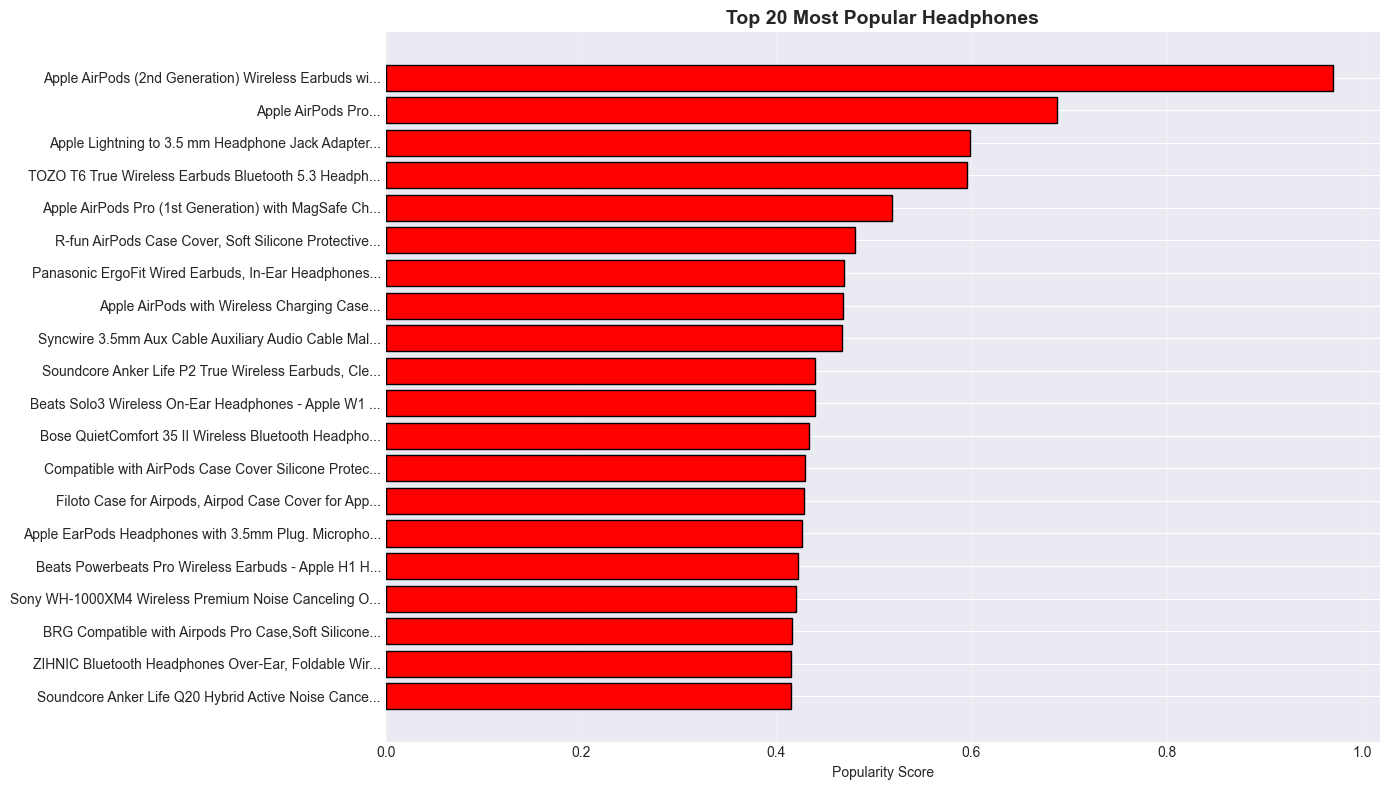


🌟 TOP 5 MOST POPULAR HEADPHONES:

1. Apple AirPods (2nd Generation) Wireless Earbuds with Lightni...
   Price: $99.00 | Rating: 4.70★ | Reviews: 585,624
   Type: Wireless | Popularity: 0.970

2. Apple AirPods Pro...
   Price: $nan | Rating: 4.80★ | Reviews: 300,544
   Type: Unknown | Popularity: 0.688

3. Apple Lightning to 3.5 mm Headphone Jack Adapter...
   Price: $7.99 | Rating: 4.70★ | Reviews: 223,181
   Type: Unknown | Popularity: 0.599

4. TOZO T6 True Wireless Earbuds Bluetooth 5.3 Headphones Touch...
   Price: $26.99 | Rating: 4.40★ | Reviews: 249,207
   Type: Wireless | Popularity: 0.595

5. Apple AirPods Pro (1st Generation) with MagSafe Charging Cas...
   Price: $249.99 | Rating: 4.70★ | Reviews: 145,034
   Type: Unknown | Popularity: 0.519



In [22]:
top_popular_hp = df_hp.nlargest(20, 'popularity_score')[['title', 'popularity_score', 'average_rating', 'rating_number', 'price', 'connectivity']]

plt.figure(figsize=(14, 8))
plt.barh(range(len(top_popular_hp)), top_popular_hp['popularity_score'].values, color='red', edgecolor='black')
plt.yticks(range(len(top_popular_hp)), [t[:50] + '...' for t in top_popular_hp['title']])
plt.xlabel('Popularity Score')
plt.title('Top 20 Most Popular Headphones', fontweight='bold', fontsize=14)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n🌟 TOP 5 MOST POPULAR HEADPHONES:\n")
for i, (idx, row) in enumerate(top_popular_hp.head(5).iterrows(), 1):
    print(f"{i}. {row['title'][:60]}...")
    print(f"   Price: ${row['price']:.2f} | Rating: {row['average_rating']:.2f}★ | Reviews: {row['rating_number']:,}")
    print(f"   Type: {row['connectivity']} | Popularity: {row['popularity_score']:.3f}")
    print()

## 12. Export Results & Summary

In [23]:
print("💾 Exporting results...\n")

# Export enhanced dataset
export_cols = ['parent_asin', 'title', 'price', 'average_rating', 'rating_number',
               'price_segment', 'connectivity', 'form_factor', 'brand',
               'popularity_score', 'value_score']
df_hp[export_cols].to_csv('headphones_analysis.csv', index=False)
print("✅ headphones_analysis.csv")

# Top brands
top_brands.to_csv('headphones_top_brands.csv')
print("✅ headphones_top_brands.csv")

# Best value list
best_value_hp.to_csv('headphones_best_value.csv', index=False)
print("✅ headphones_best_value.csv")

# Summary report
summary = f"""
{'='*70}
🎧 HEADPHONES MARKET ANALYSIS SUMMARY
{'='*70}
Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}

OVERVIEW:
• Total Products: {len(df_hp):,}
• With Price Data: {df_hp['price'].notna().sum():,} ({df_hp['price'].notna().sum()/len(df_hp)*100:.1f}%)
• With Ratings: {df_hp['average_rating'].notna().sum():,} ({df_hp['average_rating'].notna().sum()/len(df_hp)*100:.1f}%)

PRICING:
• Median Price: ${df_hp['price'].median():.2f}
• Mean Price: ${df_hp['price'].mean():.2f}
• Price Range: ${df_hp['price'].min():.2f} - ${df_hp['price'].max():.2f}
• Most Common Segment: {df_hp['price_segment'].value_counts().index[0]}

QUALITY:
• Average Rating: {df_hp['average_rating'].mean():.2f}★
• Products ≥4.5★: {len(df_hp[df_hp['average_rating'] >= 4.5]):,} ({len(df_hp[df_hp['average_rating'] >= 4.5])/len(df_hp)*100:.1f}%)
• Median Reviews: {df_hp['rating_number'].median():.0f}

CONNECTIVITY:
• Wireless: {len(df_hp[df_hp['connectivity'] == 'Wireless']):,}
• Wired: {len(df_hp[df_hp['connectivity'] == 'Wired']):,}
• Wireless Premium: ${df_hp[df_hp['connectivity'] == 'Wireless']['price'].median():.2f} median

FORM FACTOR:
{df_hp['form_factor'].value_counts().to_string()}

TOP BRANDS:
{df_hp['brand'].value_counts().head(5).to_string()}

KEY INSIGHTS:
1. Budget segment (<$20) has {price_counts.values[0]:,} products
2. Wireless headphones dominate the market
3. Earbuds/In-Ear is the most popular form factor
4. {top_brands.index[0]} has the most products ({top_brands.values[0]:,})
5. Best value: {best_value_hp.iloc[0]['title'][:50]}...

{'='*70}
"""

with open('headphones_summary.txt', 'w') as f:
    f.write(summary)
print("✅ headphones_summary.txt")

print("\n" + summary)
print("\n✅ Analysis complete! All files exported.")

💾 Exporting results...

✅ headphones_analysis.csv
✅ headphones_top_brands.csv
✅ headphones_best_value.csv
✅ headphones_summary.txt


🎧 HEADPHONES MARKET ANALYSIS SUMMARY
Date: 2025-10-29 18:50

OVERVIEW:
• Total Products: 27,245
• With Price Data: 11,310 (41.5%)
• With Ratings: 27,245 (100.0%)

PRICING:
• Median Price: $18.99
• Mean Price: $44.76
• Price Range: $0.65 - $2999.00
• Most Common Segment: Budget (<$20)

QUALITY:
• Average Rating: 3.99★
• Products ≥4.5★: 4,308 (15.8%)
• Median Reviews: 156

CONNECTIVITY:
• Wireless: 9,627
• Wired: 5,083
• Wireless Premium: $29.99 median

FORM FACTOR:
form_factor
Unknown           12957
Earbuds/In-Ear    11705
Over-Ear           1561
On-Ear             1022

TOP BRANDS:
brand
Sony          637
Wireless      589
Bluetooth     448
USB           414
Sennheiser    344

KEY INSIGHTS:
1. Budget segment (<$20) has 6,313 products
2. Wireless headphones dominate the market
3. Earbuds/In-Ear is the most popular form factor
4. Sony has the most products